# 📚 Cell 1 — Imports & Config

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report
import joblib

RANDOM_STATE = 42
N_JOBS = -1

LABEL_COL = "language"
USE_PCA = True
PCA_VAR = 0.95

# ⏳ Cell 2 — Load Features

In [2]:
x = np.load('features/X.npy')
y = np.load('features/y.npy')

print(f"Features shape: {x.shape}")
print(f"Labels shape: {y.shape}")

Features shape: (712, 56)
Labels shape: (712,)


# Cell 3 — Train/Test Split

We split the dataset into training and test partitions using an 80/20 ratio and stratified sampling to preserve the class distribution across languages. This prevents evaluation bias caused by class imbalance in either split, making model comparisons fair and reliable. The held-out test set is used only for final evaluation to estimate generalization performance, as required by the project specification. 

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Cell 4 — Preprocessing Block

In this preprocessing stage, we first standardize all features using StandardScaler to ensure zero mean and unit variance, which is important for stable covariance estimation and for classifiers that are sensitive to feature scale. We then apply Linear Discriminant Analysis (LDA) with three components as a supervised dimensionality reduction method. Unlike PCA, LDA explicitly maximizes class separability by optimizing the ratio of between-class variance to within-class variance. Since LDA previously demonstrated strong class separation in the clustering and visualization stage, we adopt its three discriminative components as the final feature representation for all classifiers. This allows us to reduce dimensionality while preserving the most informative structure for language classification.

Pipelining the preprocessing procedure prevents data leakage between train and test data.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

pre_lda3 = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LDA(n_components=3)),
])

# Cell 5 — Define Models + Hyperparameter Grids

We evaluate a diverse set of classifiers: SVM (strong margins in high-dimensional feature spaces), MLP (nonlinear decision boundaries), Decision Tree / Random Forest (nonlinear models with interpretability and ensemble robustness), and Gaussian Naïve Bayes (fast probabilistic baseline). For each model, we define a small hyperparameter grid and tune it via stratified cross-validation on the training set, ensuring that model selection does not leak information from the test set.

In [5]:
pre = pre_lda3

models = {
    "SVM_RBF": (
        SVC(kernel="rbf"),
        {
            "clf__C": [0.1, 1, 10],
            "clf__gamma": ["scale", "auto"],
        }
    ),
    "MLP": (
        MLPClassifier(max_iter=400, random_state=RANDOM_STATE),
        {
            "clf__hidden_layer_sizes": [(128,), (256,), (128, 64)],
            "clf__alpha": [1e-4, 1e-3],
            "clf__learning_rate_init": [1e-3, 5e-4],
        }
    ),
    "DecisionTree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            "clf__max_depth": [None, 10, 20],
            "clf__min_samples_split": [2, 10],
        }
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300),
        {
            "clf__max_depth": [None, 10, 20],
            "clf__max_features": ["sqrt", "log2"],
        }
    ),
    "NaiveBayes": (
        GaussianNB(),
        {}
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Cell 6 — Train and Keep Best Estimators

Model training is performed using nested preprocessing + classifier pipelines and hyperparameter tuning via 5-fold stratified cross-validation. We optimize for macro F1-score to treat all languages equally, even if class frequencies slightly differ. The best configuration for each model is selected strictly using the training split and cross-validation, allowing an unbiased final evaluation on the held-out test set.

In [6]:
best_models = {}
cv_results = []

for name, (clf, grid) in models.items():
    pipe = Pipeline([
        ("pre", pre),
        ("clf", clf),
    ])
    search = GridSearchCV(
        pipe,
        param_grid=grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=N_JOBS,
        refit=True,
        verbose=0
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    cv_results.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_best_f1_macro": search.best_score_
    })

cv_df = pd.DataFrame(cv_results).sort_values("cv_best_f1_macro", ascending=False)
cv_df

,model,best_params,cv_best_f1_macro
0,SVM_RBF,"{'clf__C': 0.1, 'clf__gamma': 'scale'}",0.998275
1,MLP,"{'clf__alpha': 0.0001, 'clf__hidden_layer_size...",0.998275
4,NaiveBayes,{},0.998275
3,RandomForest,"{'clf__max_depth': None, 'clf__max_features': ...",0.996458
2,DecisionTree,"{'clf__max_depth': None, 'clf__min_samples_spl...",0.984148


# Cell 7 — Detailed Test Evaluation

In this section, we evaluate all trained classifiers on the held-out test set using multiple performance metrics. In addition to overall accuracy, we compute precision, recall, and F1-score using both **macro** and **weighted** averaging. Macro-averaged metrics treat all language classes equally and provide a fair assessment of performance across classes, while weighted metrics account for class frequency and reflect overall effectiveness on the dataset. The models are then ranked based on macro F1-score to ensure balanced comparison and to identify the most robust classifier for the language identification task.

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

evaluation_rows = []

for name, est in best_models.items():
    y_pred = est.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    evaluation_rows.append({
        "model": name,
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f_macro,
        "precision_weighted": p_weighted,
        "recall_weighted": r_weighted,
        "f1_weighted": f_weighted,
    })

metrics_df = pd.DataFrame(evaluation_rows).sort_values("f1_macro", ascending=False)
metrics_df

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,SVM_RBF,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,MLP,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,RandomForest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,NaiveBayes,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,DecisionTree,0.986014,0.986111,0.986111,0.986111,0.986014,0.986014,0.986014


# Cell 8 — Per-Class Classification Reports

The per-class classification reports show that most models achieve perfect performance across all four languages (German, Italian, Korean, and Spanish), with precision, recall, and F1-scores equal to 1.00. In particular, SVM (RBF), MLP, Random Forest, and Naïve Bayes demonstrate flawless classification on the test set, indicating that the three LDA components provide highly discriminative features for language separation. In our oppinion there is a problem in the primary provided dataset and the labels are easily separable.

The Decision Tree model shows slightly lower performance for Korean and Spanish (F1-score ≈ 0.97), resulting in an overall accuracy of 98.6%. This minor drop suggests that while tree-based single estimators can capture nonlinear boundaries, they may be slightly less stable compared to ensemble methods like Random Forest.

Overall, the results indicate that the LDA-based feature representation achieves near-perfect class separability, confirming that the discriminative subspace extracted by LDA is highly effective for this language identification task.

In [8]:
for name, est in best_models.items():
    print("=" * 90)
    print(f"Model: {name}")
    y_pred = est.predict(X_test)
    print(classification_report(y_test, y_pred, digits=4))

Model: SVM_RBF
              precision    recall  f1-score   support

      German     1.0000    1.0000    1.0000        35
     Italian     1.0000    1.0000    1.0000        36
      Korean     1.0000    1.0000    1.0000        36
     Spanish     1.0000    1.0000    1.0000        36

    accuracy                         1.0000       143
   macro avg     1.0000    1.0000    1.0000       143
weighted avg     1.0000    1.0000    1.0000       143

Model: MLP
              precision    recall  f1-score   support

      German     1.0000    1.0000    1.0000        35
     Italian     1.0000    1.0000    1.0000        36
      Korean     1.0000    1.0000    1.0000        36
     Spanish     1.0000    1.0000    1.0000        36

    accuracy                         1.0000       143
   macro avg     1.0000    1.0000    1.0000       143
weighted avg     1.0000    1.0000    1.0000       143

Model: DecisionTree
              precision    recall  f1-score   support

      German     1.0000    1.

# Cell 9 — Confusion Matrices

There's nothing special to say; the only mistakes are made by the decision tree model; it has classified a Korean as a Spanish and vice versa.

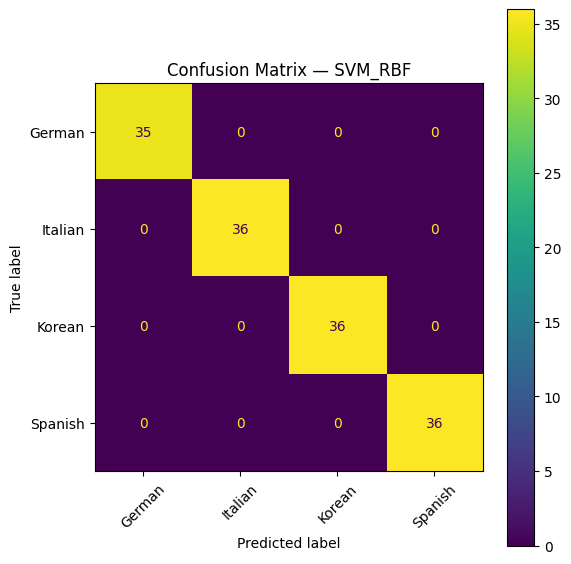

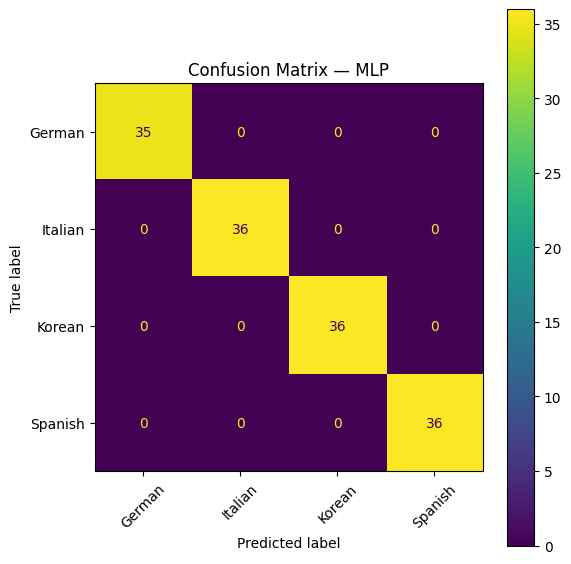

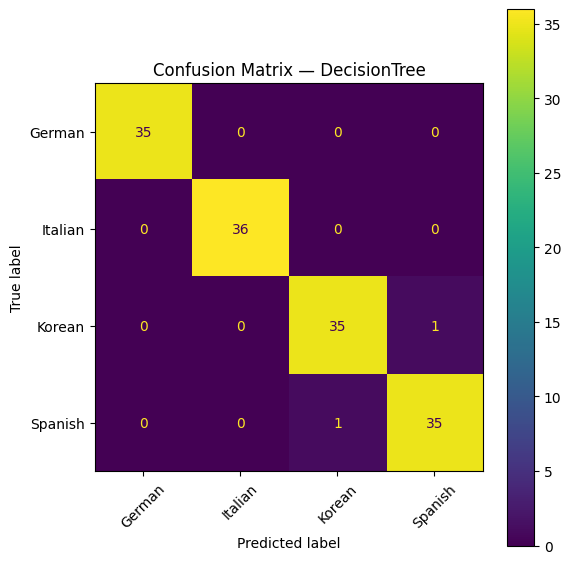

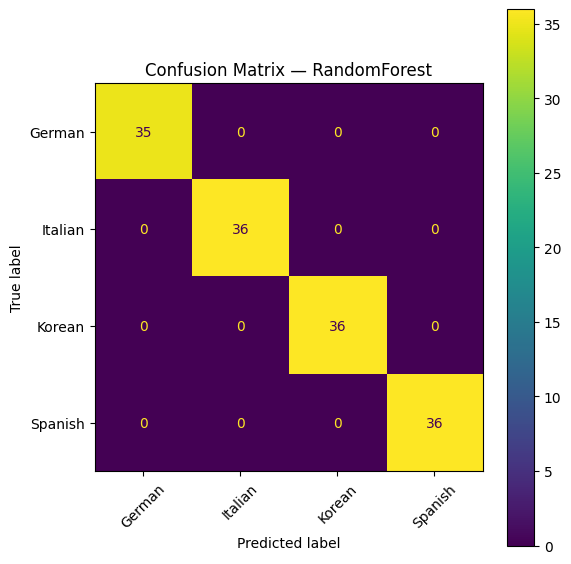

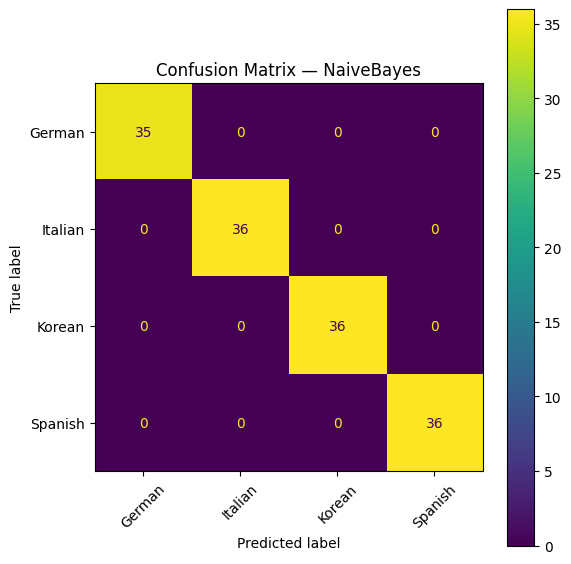

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

labels = np.unique(y_test)

for name, est in best_models.items():
    y_pred = est.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, xticks_rotation=45, values_format="d")
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

# Cell 10 — Model Ranking Summary

In [10]:
ranked_models = metrics_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)
ranked_models

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,SVM_RBF,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,MLP,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,RandomForest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,NaiveBayes,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,DecisionTree,0.986014,0.986111,0.986111,0.986111,0.986014,0.986014,0.986014
